In [7]:
!pip install nltk

In [8]:
!pip install wordcloud

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [10]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [11]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [13]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [14]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):

    # lowercase
    text = text.lower()

    # remove punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # tokenization
    words = word_tokenize(text)

    # remove stopwords and apply stemming
    words = [stemmer.stem(word) for word in words if word not in stop_words]

    return " ".join(words)

In [15]:
nltk.download('punkt_tab')
df['clean_review'] = df['review'].apply(preprocess_text)
df.head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,1,one review mention watch oz episod youll hook ...
1,A wonderful little production. <br /><br />The...,1,wonder littl product br br film techniqu unass...
2,I thought this was a wonderful way to spend ti...,1,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,0,basic there famili littl boy jake think there ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter mattei love time money visual stun film...


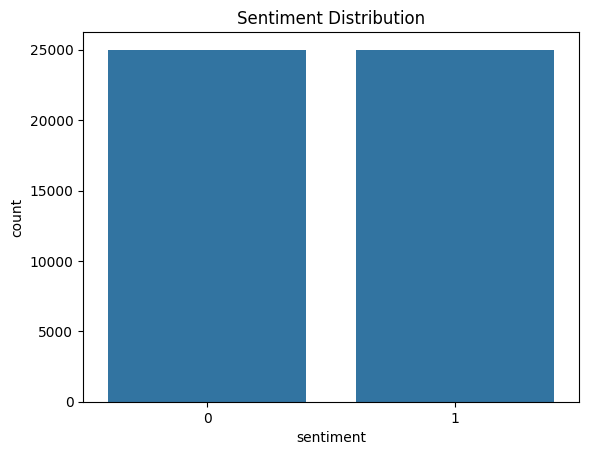

In [16]:
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

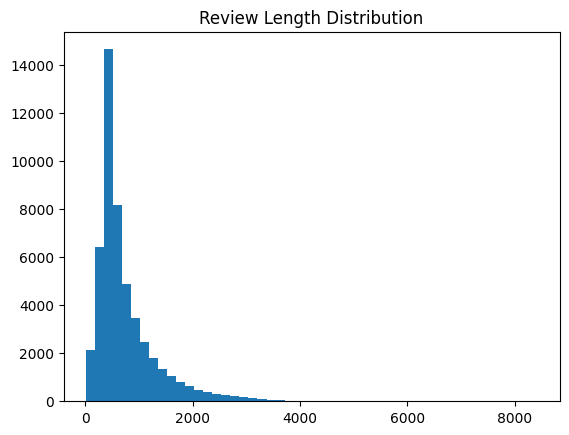

In [17]:
df['review_length'] = df['clean_review'].apply(len)

plt.hist(df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.show()

In [18]:
from collections import Counter

all_words = " ".join(df['clean_review']).split()

word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

print(common_words)

[('br', 114890), ('movi', 98983), ('film', 92081), ('one', 53314), ('like', 43990), ('time', 29805), ('good', 28988), ('make', 28613), ('get', 27750), ('see', 27693), ('charact', 27602), ('watch', 27281), ('even', 25046), ('stori', 24274), ('would', 24024), ('realli', 22952), ('scene', 20706), ('show', 19407), ('well', 19303), ('look', 19284)]


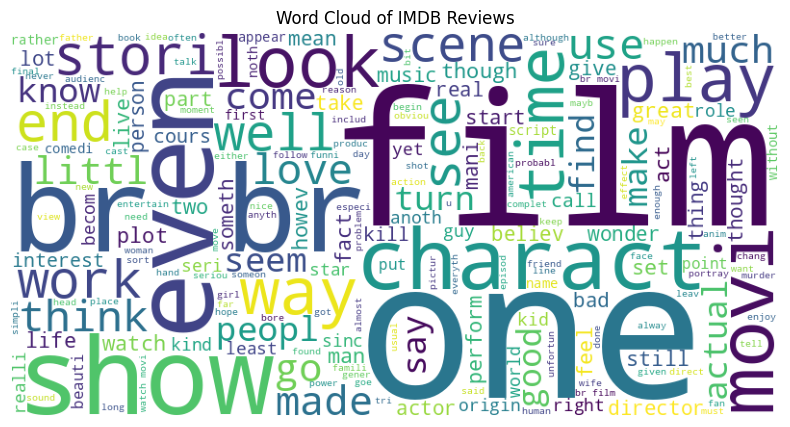

In [19]:
from wordcloud import WordCloud

text = " ".join(df['clean_review'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of IMDB Reviews")
plt.show()

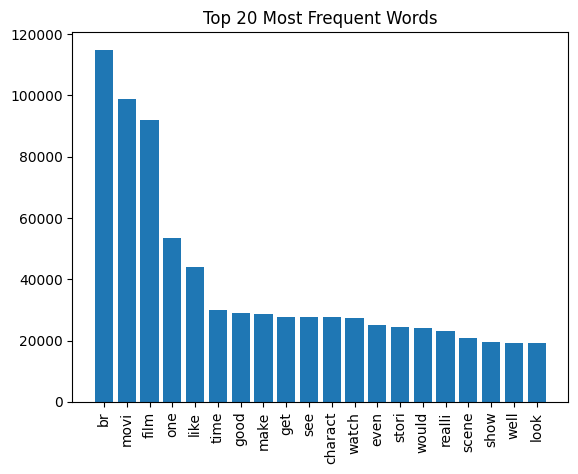

In [20]:
words = [word[0] for word in common_words]
counts = [word[1] for word in common_words]

plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Top 20 Most Frequent Words")
plt.show()

In [21]:
bow_vectorizer = CountVectorizer(max_features=5000)

X_bow = bow_vectorizer.fit_transform(df['clean_review'])

print(X_bow.shape)

(50000, 5000)


In [22]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),   # unigrams + bigrams
    min_df=5,
    max_df=0.7
)

X_tfidf = tfidf_vectorizer.fit_transform(df['clean_review'])

In [23]:
y = df['sentiment']

In [24]:
from sklearn.model_selection import train_test_split

# Using TF-IDF features
X = X_tfidf
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(40000, 10000) (10000, 10000)


In [25]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.8634


In [26]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=2000,
    C=5,
    solver='liblinear'
)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8931


In [27]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.8895


In [28]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "SVM"],
    "Accuracy": [nb_accuracy, lr_accuracy, svm_accuracy]
})

print(results)

                 Model  Accuracy
0          Naive Bayes    0.8634
1  Logistic Regression    0.8931
2                  SVM    0.8895


### Classification Report for Naive Bayes

In [39]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("Classification Report - Naive Bayes:\n")
print(classification_report(y_test, y_pred_nb))

Classification Report - Naive Bayes:

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4961
           1       0.86      0.88      0.87      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



### Classification Report for Logistic Regression

In [40]:
print("Classification Report - Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr))

Classification Report - Logistic Regression:

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.91      0.90      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



### Classification Report for SVM

In [41]:
print("Classification Report - SVM:\n")
print(classification_report(y_test, y_pred_svm))

Classification Report - SVM:

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



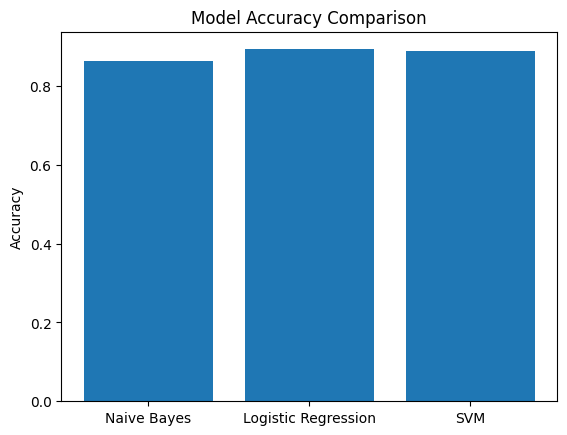

In [42]:
models = ['Naive Bayes', 'Logistic Regression', 'SVM']
accuracies = [nb_accuracy, lr_accuracy, svm_accuracy]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

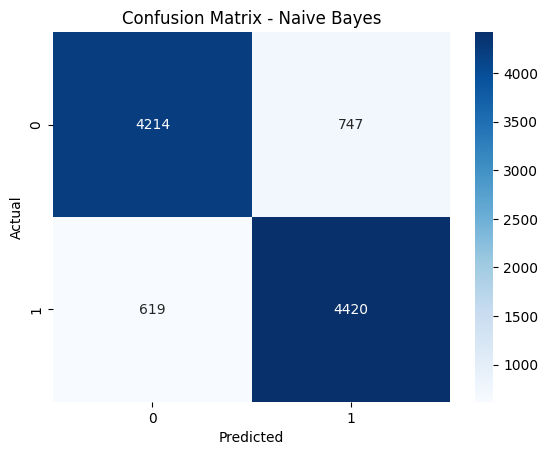

In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [44]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10]
}

grid = GridSearchCV(LogisticRegression(max_iter=1000),
                    param_grid,
                    cv=5,
                    scoring='accuracy')

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 1}
Best Score: 0.890475


In [45]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "SVM"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm)
    ],

    "Precision": [
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_svm)
    ],

    "Recall": [
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_svm)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_svm)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0          Naive Bayes    0.8634   0.855429  0.877158  0.866157
1  Logistic Regression    0.8931   0.884094  0.906728  0.895268
2                  SVM    0.8895   0.881645  0.901766  0.891592
